In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Heston model parameters
S0 = 100
K = S0
T = 1
r = 0.05
v0 = 0.04
theta = 0.04
kappa = 9
sigma = 0.3
rho = -0.5


In [6]:
# Chooser option parameters
t_choice = 0.5
optionType = 'call'

# Monte Carlo simulation parameters
Nsim = 1000
Nt = 100
dt = T / Nt

# Heston model simulation
S = np.zeros((Nsim, Nt + 1))
S[:, 0] = S0
v = np.zeros((Nsim, Nt + 1))
v[:, 0] = v0

for i in range(1, Nt + 1):
    Z1 = np.random.standard_normal(Nsim)
    Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.standard_normal(Nsim)
    v[:, i] = np.abs(v[:, i - 1] + kappa * (theta - v[:, i - 1]) * dt + sigma * np.sqrt(v[:, i - 1] * dt) * Z2)
    S[:, i] = S[:, i - 1] * np.exp((r - 0.5 * v[:, i - 1]) * dt + np.sqrt(v[:, i - 1] * dt) * Z1)


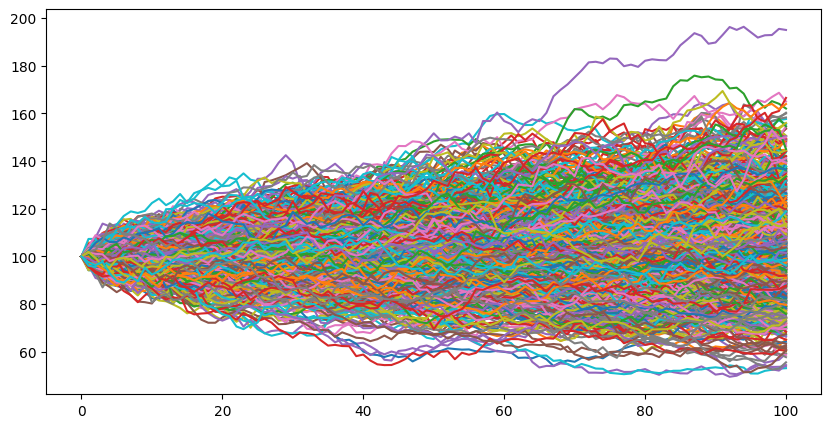

In [13]:
# Chooser option price
S_choice = int(t_choice / dt)

if optionType == 'call':
    payoff = np.maximum(S[:, S_choice] - K, 0)
else:
    payoff = np.maximum(K - S[:, S_choice], 0)

option_price = np.exp(-r * (T - t_choice)) * np.mean(payoff)
std_error = np.exp(-r * (T - t_choice)) * np.std(payoff) / np.sqrt(Nsim)

# Visualization of stock price simulation
plt.figure(figsize=(10, 5))
plt.plot(S.T)
plt.show()